In [1]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import statsmodels.api as sm
from difflib import SequenceMatcher
import enum

class Models(enum.Enum):
    GPT3_5 = "gpt-3.5-turbo"
    GPT4 = "gpt-4-turbo"
    GPT4o = "gpt-4o"
    LLAMA3 = "llama3-70b-8192"
    MIXTRAL8_7 = "mixtral-8x7b-32768"
    MIXTRAL8_22 = 'mixtral-8x22b-65536'

In [2]:
CWE_LIST = ["CWE-89", "CWE-22", "CWE-79"]

MODELS = [Models.MIXTRAL8_7, Models.MIXTRAL8_22, Models.LLAMA3, Models.GPT3_5, Models.GPT4o, Models.GPT4]
# MODELS = [Models.MIXTRAL8_7,  Models.GPT3_5]
# MODELS = [  Models.MIXTRAL8_7]
# MODELS = [Models.LLAMA3]

# INFERENCE_RESULTS_FOLDER = "./run1/inference"
# GENERATED_FILES = "./run1/files.csv"
# INFERENCE_RESULTS_FOLDER = "./inference"
# GENERATED_FILES = "./files.csv"

BUGGY_FILES_FOLDER = "./source_files"
MAX_CHARS = 250001

# Setup

## Definition of files

In [3]:
files_dict = {
    406: {
        "main_padding": "/php/406/406_whole.php",
        "buggy_content": "/php/406/406_smallestBuggy.php",
        "buggy_line": "$selectedIds = explode(',', $selectedIds);",
        "split_string": "// -x-",
        "CWE_ID": "CWE-89"
    },
    408: {
        'main_padding': '/php/408/408_whole.php',
        "additional_padding": ["/php/408/additional_padding.php"],
        "buggy_content": "/php/408/408_smallestBuggy.php",
        "buggy_line": '''SELECT * FROM ' . static::table_name() . ' WHERE ' . $property .  ''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-89"
    },
    405: {
        'main_padding': '/php/405/405_whole.php',
        "additional_padding": ["/php/405/additional_padding.php"],
        "buggy_content": "/php/405/405_smallestBuggy.php",
        "buggy_line": '''$where = "WHERE group_ID = {$group_id}";''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-89"
    },
    4921: {
        'main_padding': '/go/4921/4921_modifiedFile.go',
        "additional_padding": ["/go/4921/additional_padding.go"],
        "buggy_content": "/go/4921/4921_smallestBuggy.go",
        "buggy_line": '''order := fmt.Sprintf("`%s` %s", DefaultQuery(c, "sort_by", "id"), sort)''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-89"
    },
    4928: {
        'main_padding': '/php/4928/4928_modifiedFile.php',
        "additional_padding": ["/php/4928/additional_padding.php"],
        "buggy_content": "/php/4928/4928_smallestBuggy.php",
        "buggy_line": '''return @mysqli_real_escape_string($fmdb->dbh, $data);''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-89"
    },
    3989:{
        'main_padding': '/js/3989/3989_whole.js',
        "additional_padding": ["/js/3989/additional_padding.js"],
        "buggy_content": "/js/3989/3989_smallestBuggy.js",
        "buggy_line": '''`window[${idJSON}].push(${serializedCacheArgs});`,''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-79"
    },
    3976:{
        'main_padding': '/js/3976/3976_whole.js',
        "additional_padding": ["/js/3976/additional_padding.js"],
        "buggy_content": "/js/3976/3976_smallestBuggy.js",
        "buggy_line": '''const header = container.querySelector(`h${level}`);''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-79"
    },
    3968:{
        'main_padding': '/php/3968/3968_whole.php',
        "additional_padding": ["/php/3968/additional_padding.php"],
        "buggy_content": "/php/3968/3968_smallestBuggy.php",
        "buggy_line": '''$response['data']['path'] = $model->path;''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-79"
    },
    300:{
        'main_padding': '/php/300/300_modifiedFile.php',
        "additional_padding": ["/php/300/additional_padding.php"],
        "buggy_content": "/php/300/300_smallestBuggy.php",
        "buggy_line": '''<td>' . $item->id . '</td>''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-79"
    },
    302:{
        'main_padding': '/rb/302/302_modifiedFile.rb',
        "additional_padding": ["/rb/302/additional_padding.rb"],
        "buggy_content": "/rb/302/302_smallestBuggy.rb",
        "buggy_line": '''@filter = params[:filter] || "*"''',
        "split_string": "# -x-",
        "CWE_ID": "CWE-79"
    },
    5422:{
        'main_padding': '/go/5422/5422_modifiedFile.go',
        "additional_padding": ["/go/5422/additional_padding.go"],
        "buggy_content": "/go/5422/5422_smallestBuggy.go",
        "buggy_line": '''outdir := filepath.Join(basePath, name)''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-22"
    },
    5396:{
        'main_padding': '/java/5396/5396_modifiedFile.java',
        "additional_padding": ["/java/5396/additional_padding.java"],
        "buggy_content": "/java/5396/5396_smallestBuggy.java",
        "buggy_line": '''URI uri = toURI(fileUri);''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-22"
    },
    5404:{
        'main_padding': '/go/5404/5404_modifiedFile.go',
        "additional_padding": ["/go/5404/additional_padding.go"],
        "buggy_content": "/go/5404/5404_smallestBuggy.go",
        "buggy_line": '''target := filepath.Join(dst, name)''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-22"
    },
    5414:{
        'main_padding': '/js/5414/5414_modifiedFile.js',
        "additional_padding": ["/js/5414/additional_padding.js"],
        "buggy_content": "/js/5414/5414_smallestBuggy.js",
        "buggy_line": '''var filename = path.join(__dirname, "public", req.url.path_list.join("/"));''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-22"
    },
    493:{
        'main_padding': '/py/493/493_modifiedFile.py',
        "additional_padding": ["/py/493/additional_padding.py"],
        "buggy_content": "/py/493/493_smallestBuggy.py",
        "buggy_line": '''return FileResponse(f"user_images/pfp/{username}", media_type='image/gif')''',
        "split_string": "# -x-",
        "CWE_ID": "CWE-22"
    },
}

## Import CSV

In [4]:
def import_csv(cwe_list, models, files_path, inference_results_folder):
    df_files = pd.read_csv(files_path)
    df_files = df_files[df_files['target_length'] <= MAX_CHARS]

    combined_df = pd.DataFrame()

    for model in models:
        df_model = pd.read_csv(inference_results_folder+"/"+model.value+".csv")
        for cwe_id in cwe_list:
        
            # print(f"Processing CWE {cwe_id} for model {model}")
            df_cwe = df_files[(df_files['CWE_ID'] == cwe_id)]

            if len(df_cwe) == 0:
                # print(f"No files found for CWE {cwe_id}")
                continue

            df_combined = pd.merge(df_model, df_cwe, on='file_id', how='inner')

            _check_files(df_model, df_cwe)


            combined_df = pd.concat([combined_df, df_combined])

    combined_df = combined_df[['content', 'model_output', 'prompt', 'file_id', 'database_file_id', 'length', 'bug_position', 'target_bug_position', 'target_length', 'CWE_ID', 'model']]
    
    return combined_df

# Check files function
def _check_files(df_data, df_files):
    file_ids_data = df_data['file_id'].value_counts()
    file_ids_files = df_files['file_id'].unique()

    problems = []
    for file_id in file_ids_files:
        if file_id not in file_ids_data or file_ids_data[file_id] != 1:
            problems.append(file_id)
        
    # if len(df_data) != len(df_files):
        # print(f"Data count mismatch: Expected {len(df_files)}, got {len(df_data)}.")

    # if problems:
    #     print(f"Some file_ids are missing the required number of entries in the data:")
    #     for file_id in problems:
    #         count = file_ids_data[file_id] if file_id in file_ids_data else 0
    # else:
    #     print("All file_ids have the correct number of entries.")


## Extracting functions for classification

In [5]:
def extract_code_or_return_original(text):
    pattern = r"```([a-zA-Z]+)\n(.*?)```"
    matches = list(re.finditer(pattern, text, re.DOTALL))

    if not matches:
        return text

    results = []
    for match in matches:
        results.append(match.group(2).strip())

    return "\n".join(results)

def clean_whitespace(text):
    text = text.replace('\n', ' ')
    text = re.sub(r'\s+', ' ', text)
    return text.strip().strip('`.')

def remove_spaces(text):
    return text.replace(' ', '')

def get_removed_lines(patch):
    removed_lines = re.findall(r'^-.*$', patch, re.MULTILINE)
    removed_lines = [line[1:] for line in removed_lines]
    return ' '.join(removed_lines)

def extract_bug_line(model_output):
    bug_line_pattern = re.compile(r'(Bugged\s*)?[ -]*(Line|BL)\s*[:#]\s*(.*?)(?=BUG FOUND:)', re.IGNORECASE | re.DOTALL)
    bug_line_pattern_simple = re.compile(r'(Bugged)?[ -]*(Line|BL) *[:#]', re.IGNORECASE)

    if(len(re.split(bug_line_pattern, model_output)) < 3):
        bug_line = re.split(bug_line_pattern_simple, model_output)[-1].strip()
    else:
        bug_line = re.split(bug_line_pattern, model_output)[-2].strip()

    bug_line = extract_code_or_return_original(bug_line).strip()

    match = re.search(r'`([^`]+)`', bug_line)
    if match:
        bug_line =  match.group(0)

    bug_line = clean_whitespace(bug_line)
    return bug_line
    
def has_bug_line(model_output):
    code = extract_code_or_return_original(model_output)

    bug_line_pattern = re.compile(r'(Bugged\s*)?[ -]*(Line|BL)\s*[:#]\s*(.*?)(?=BUG FOUND:)', re.IGNORECASE | re.DOTALL)
    bug_line_pattern_simple = re.compile(r'(Bugged)?[ -]*(Line|BL) *[:#]', re.IGNORECASE)

    _has_bug_line = bool(bug_line_pattern.search(model_output))

    if not _has_bug_line:
        return False
    
    bug_line = extract_bug_line(model_output)
    bug_line = remove_spaces(clean_whitespace(bug_line)).strip()

    if(len(bug_line) == 0):
        return False

    if(_has_bug_line and ('BL: None'.lower() not in model_output.lower() or "BUG FOUND: NO".lower() not in model_output.lower())):
        return True
    
    if code and code != model_output:
        return True

# Clean patch function
def clean_patch(patch):
    return re.sub(r'^[+-]', '', patch, flags=re.MULTILINE)

In [6]:
def load_buggy_file(filepath):
    with open(BUGGY_FILES_FOLDER+filepath, 'r') as file:
        return file.read()

In [7]:
def classify(record, file_dict):
    model_output = record['model_output']

    classification = None
    bug_line = None
    bug_line_in_content = False

    pattern_yes = re.compile(r"bug\s*found\s*:\s*yes", re.IGNORECASE)
    pattern_no = re.compile(r"bug\s*found\s*:\s*no", re.IGNORECASE)

    has_bug_true_indication = bool(re.search(pattern_yes, model_output))
    has_bug_false_indication = bool(re.search(pattern_no, model_output))
    _has_bug_line = has_bug_line(model_output)

    if has_bug_false_indication: 
        classification = 'FN'
    elif not _has_bug_line:
        classification = 'FN'
    else:
        bug_line = remove_spaces(extract_bug_line(model_output))

        buggy_content = remove_spaces(load_buggy_file(file_dict[record['database_file_id']]['buggy_content']))
        
        if bug_line in buggy_content:
            bug_line_in_content = True
            
        
        if (len(bug_line) > 0 and bug_line_in_content):
            classification = 'TP'
        else:
            classification = 'FP' 
        
    return pd.Series([classification, bug_line])

# Prepare dataframe function
def prepare_df(df, file_dict):
    df[['classification', 'bug_line']] = df.apply(lambda record: classify(record, file_dict), axis=1)
    return df

## Heatmap plotting

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def generate_heatmaps(data, group_by, title_suffix='', save_path='./plots'):
    # Define the classification mapping and colors
    colors = ["red", "white", "green"]
    nodes = [0.0, 0.5, 1.0]
    cmap = mcolors.LinearSegmentedColormap.from_list("", list(zip(nodes, colors)))
    norm = mcolors.Normalize(vmin=-1, vmax=1)

    groups = data.groupby(group_by)

    for name, group in groups:
        matrix, x_labels, y_labels, annotations = create_classification_matrix(group)
        title = f"{title_suffix} - {name}"
        plot_heatmap(matrix, x_labels, y_labels, annotations, cmap, norm, title, save_path)

def create_classification_matrix(df):
    classification_mapping = {'TP': 1, 'FP': -1, 'TN': 0, 'FN': -1}
    # Create mappings based on unique entries in 'target_bug_position' and 'target_length'
    bug_pos_mapping = {val: idx for idx, val in enumerate(sorted(df['target_bug_position'].unique()))}
    file_char_mapping = {val: idx for idx, val in enumerate(sorted(df['target_length'].unique()))}
    
    # Initialize the matrix and count matrix
    matrix = np.zeros((len(file_char_mapping), len(bug_pos_mapping)))
    count_matrix = np.zeros((len(file_char_mapping), len(bug_pos_mapping)))

    # Populate matrix and count matrix
    for _, row in df.iterrows():
        file_idx = file_char_mapping[row['target_length']]
        bug_idx = bug_pos_mapping[row['target_bug_position']]
        classification_value = classification_mapping[row['classification']]
        matrix[file_idx][bug_idx] += classification_value
        count_matrix[file_idx][bug_idx] += 1

    # Calculate averages and prepare annotations
    annotations = np.zeros_like(matrix, dtype=object)
    for i in range(len(file_char_mapping)):
        for j in range(len(bug_pos_mapping)):
            if count_matrix[i][j] > 0:
                avg_value = matrix[i][j] / count_matrix[i][j]
                matrix[i][j] = avg_value
                annotations[i][j] = f"{avg_value:.2f} \n ({int(count_matrix[i][j])})"
            else:
                annotations[i][j] = ""

    return matrix, list(bug_pos_mapping.keys()), list(file_char_mapping.keys()), annotations

def plot_heatmap(matrix, x_labels, y_labels, annotations, cmap, norm, title, save_path):
    plt.figure(figsize=(20, 2))
    sns.heatmap(matrix, annot=annotations, fmt="", cmap=cmap, norm=norm, xticklabels=x_labels, yticklabels=y_labels, annot_kws={"size": 6})
    plt.title(title)
    plt.xlabel('Bug Positions')
    plt.ylabel('File Characters')
    # plt.savefig(f"{save_path}/heatmap_{title.replace(' ', '_')}.png")
    plt.show()

# Execution

In [9]:
runs = {
    'run1': {
        'files': './files.csv',
        'inference': './run1/inference'
    },
    'run2': {
        'files': './files.csv',
        'inference': './run2/inference'
    },
    'run3': {
        'files': './files.csv',
        'inference': './run3/inference'
    },
    'run4': {
        'files': './files.csv',
        'inference': './run4/inference'
    },
    # TODO add runs from ./run 4 run 5 if needed (if only opensource models, loading must be adapted!!)

}
df_total = pd.DataFrame()
for run in runs:
    files_path = runs[run]['files']
    inference_results_folder = runs[run]['inference']
    combined_df = import_csv(CWE_LIST, MODELS, files_path, inference_results_folder)
    df = prepare_df(combined_df, files_dict)
    # add run column
    df['run'] = run
    df_total = pd.concat([df_total, df])
df = df_total


# previious preparation 
# combined_df = import_csv(CWE_LIST, MODELS)
# df = prepare_df(combined_df, files_dict)

FileNotFoundError: [Errno 2] No such file or directory: './run4/inference/gpt-4-turbo.csv'

# Generate Heatmaps -> Change following commands based on desired grouping

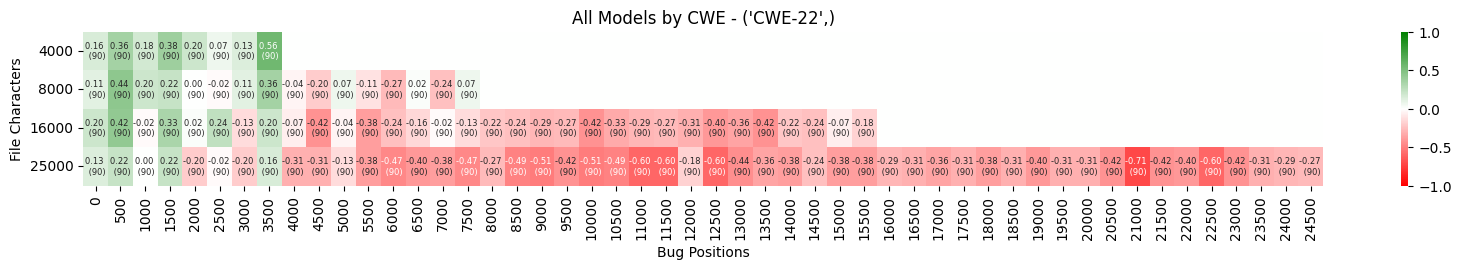

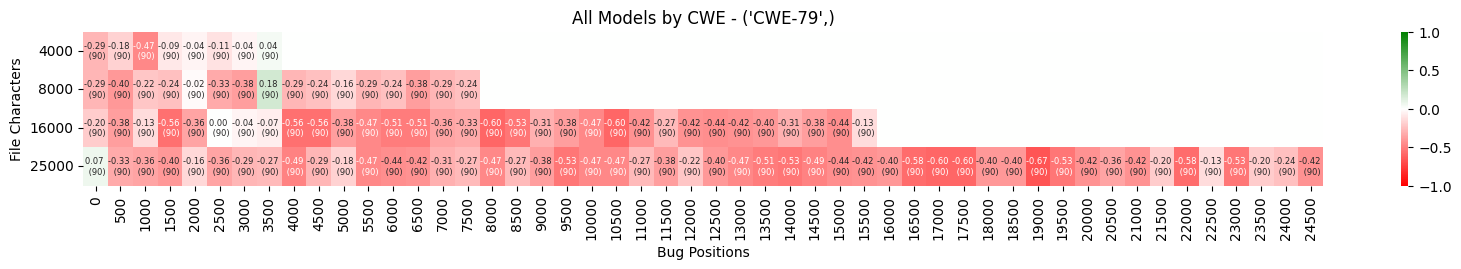

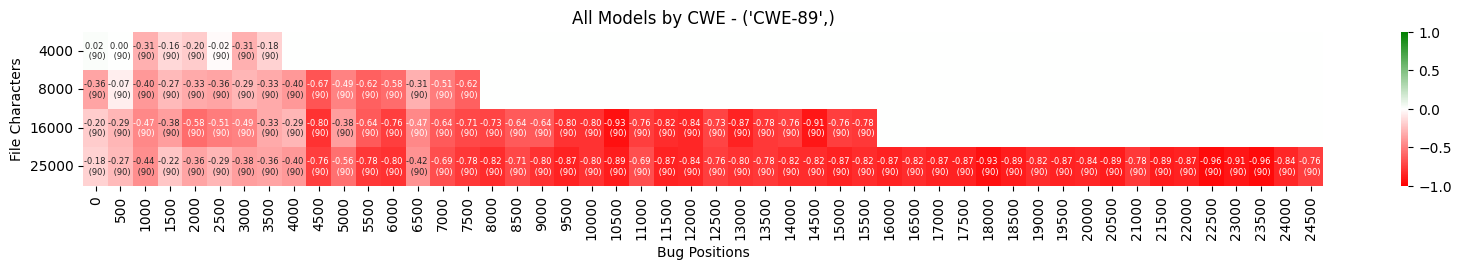

In [ ]:
# To display overview of all files aggregated per model
# generate_heatmaps(df, 'model', 'All Files per Model')

# To display overview of all files aggregated per CWE -> simple comparision across models
# generate_heatmaps(df[df['CWE_ID']=='CWE-89'], 'model', 'CWE-89 per Model')

# To display overall CWE results
generate_heatmaps(df, ['CWE_ID'], 'All Models by CWE')

# To display results per model per CWE
# generate_heatmaps(df, ['CWE_ID','model'], 'All Models by CWE')

# Test plotting -> accumulation across runs

In [ ]:
# df_total = pd.DataFrame()
# for run in runs:
#     files_path = runs[run]['files']
#     inference_results_folder = runs[run]['inference']
#     combined_df = import_csv(CWE_LIST, MODELS, files_path, inference_results_folder)
#     df = prepare_df(combined_df, files_dict)
#     # add run column
#     df['run'] = run
#     df_total = pd.concat([df_total, df])
#     # generate_heatmaps(df_total[df_total['CWE_ID']=='CWE-22'], ['CWE_ID', 'model'], f'cummuated up to run {run}')
#     generate_heatmaps(df_total, [ 'model'], f'cummuated up to run {run}')
#     # generate_heatmaps(df_total, ['CWE_ID', 'model'], f'cummuated up to run {run}')


# Logistical Regression TODO - not completed yet

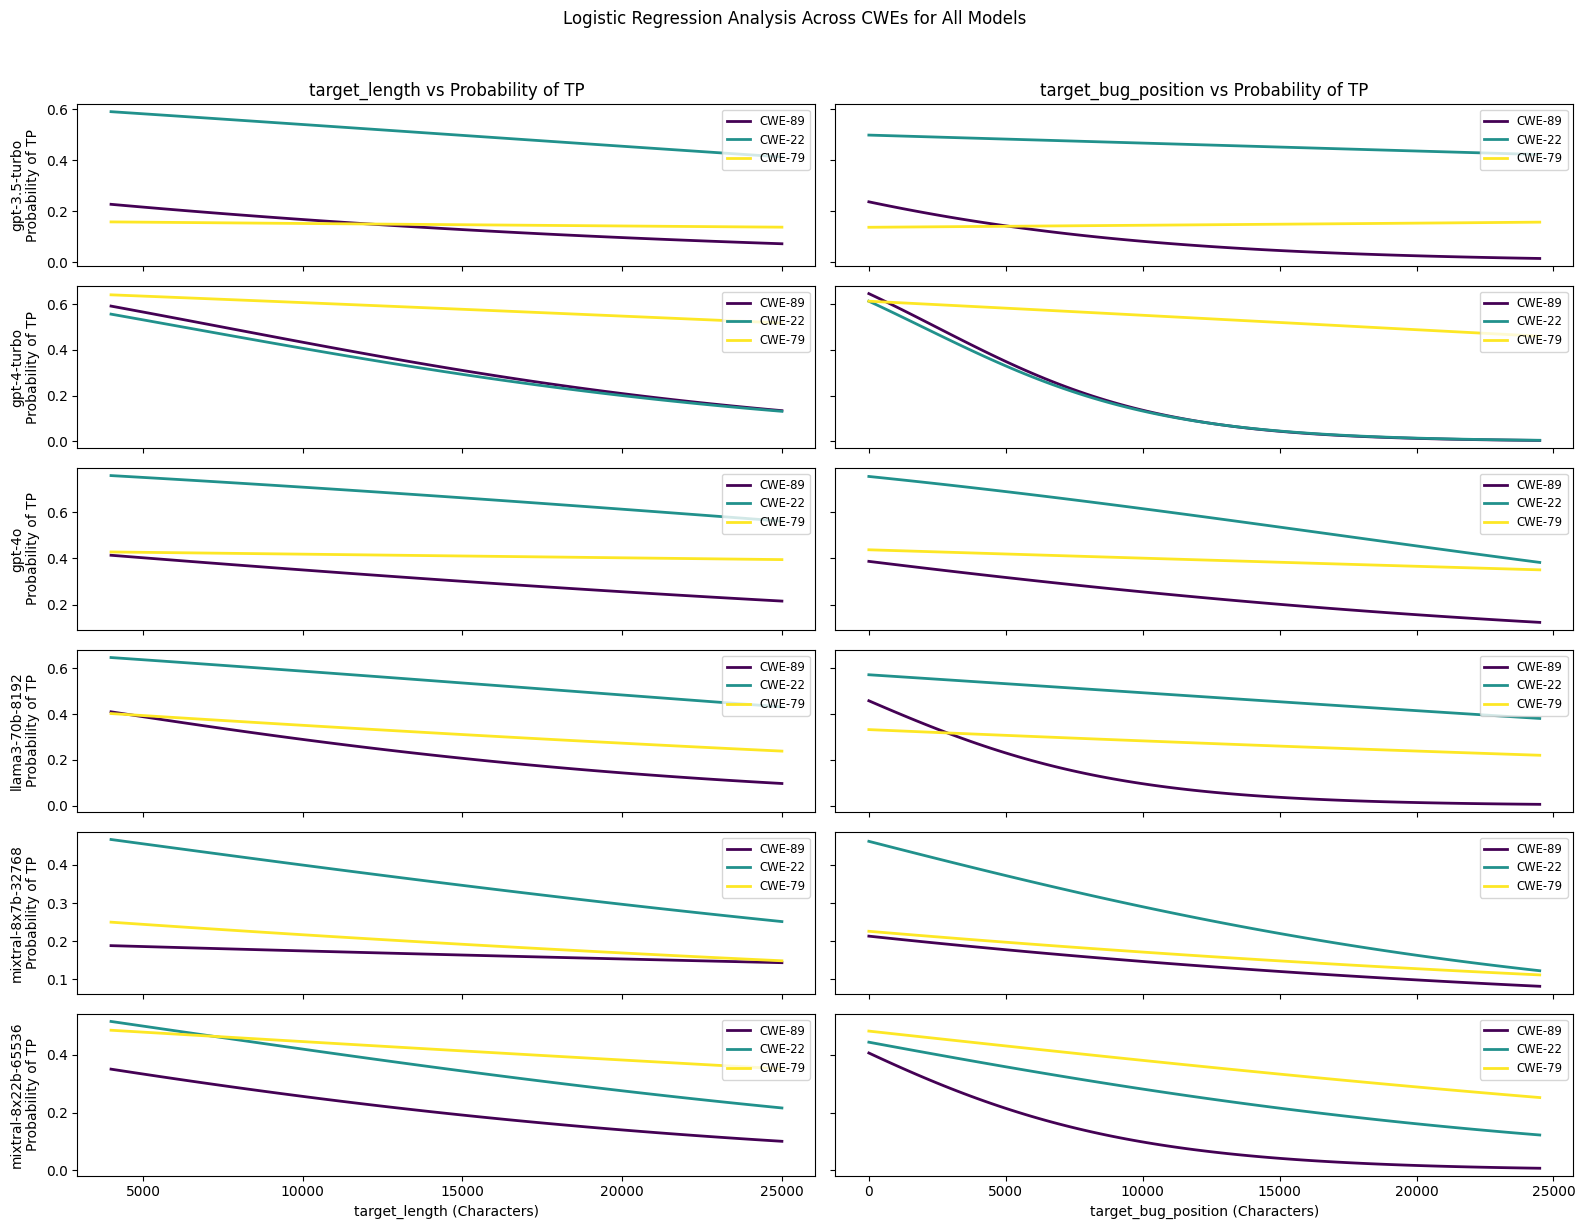

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Logistic Regression Plotting Functions
def plot_logistic_regressions_for_all_models(df, models, features, cwe_ids, save_path='./plots'):
    # Prepare the classification column for logistic regression
    df['classification_TP'] = df['classification'].apply(lambda x: 1 if x == 'TP' else 0)

    fig, axes = plt.subplots(len(models), len(features), figsize=(16, 2 * len(models)), dpi=100, sharex='col', sharey='row')
    colors = plt.cm.viridis(np.linspace(0, 1, len(cwe_ids)))  # Generate a color array

    for row, model in enumerate(models):
        for col, feature in enumerate(features):
            ax = axes[row, col] if len(models) > 1 else axes[col]
            for cwe_id, color in zip(cwe_ids, colors):
                cwe_df = df[(df['CWE_ID'] == cwe_id) & (df['model'] == model.value)]
                if not cwe_df.empty:
                    plot_logistic_regression(cwe_df, feature, 'classification_TP', cwe_id, ax, color)
            if row == len(models) - 1:
                ax.set_xlabel(f'{feature} (Characters)')
            if col == 0:
                ax.set_ylabel(f'{model.value}\nProbability of TP')
            ax.set_title(f'{feature} vs Probability of TP' if row == 0 else '')
            ax.legend(cwe_ids, loc='upper right', fontsize='small')

    fig.suptitle(f'Logistic Regression Analysis Across CWEs for All Models', y=1.02)
    plt.tight_layout()
    # plt.savefig(f"{save_path}/logistic_regression_all_models.png")
    plt.show()

def plot_logistic_regression(data, x_col, y_col, label, ax, color):
    X = sm.add_constant(data[x_col])
    y = data[y_col]
    model = sm.Logit(y, X).fit(disp=0)
    x_values = np.linspace(data[x_col].min(), data[x_col].max(), 100)
    y_probs = model.predict(sm.add_constant(x_values))
    
    label_dict = {
        "CWE-22": "CWE-22: Path Traversal",
        "CWE-89": "CWE-89: SQL Injection",
        "CWE-79": "CWE-79: XSS"
    }
    
    ax.plot(x_values, y_probs, label=f"{label_dict.get(label, label)} (p={model.pvalues[x_col]:.5f})", color=color, linewidth=2)

# Example usage
cwe_ids = ['CWE-89', 'CWE-22', 'CWE-79']  # Example CWE IDs
models = [Models.GPT3_5, Models.GPT4, Models.GPT4o, Models.LLAMA3, Models.MIXTRAL8_7, Models.MIXTRAL8_22]  # Example Models

# Filtering the dataframe to include only relevant rows for logistic regression
# df_filtered = df[(df['classification'] == 'TP') | (df['classification'] == 'FN')]
df_filtered = df
df_filtered = df_filtered.dropna(subset=['target_length', 'target_bug_position'])  # Ensure no NaN values in necessary columns

# Plotting logistic regression for each model in a single plot
plot_logistic_regressions_for_all_models(df_filtered, models, ['target_length', 'target_bug_position'], cwe_ids)


# Classification

In [ ]:
# df group by file_nr and display count of clasification
# to display some interesting statistics
df_grouped = df.groupby(["CWE_ID",'database_file_id', 'classification', ]).size().unstack(fill_value=0)
df_grouped

classification            FN    FP    TP
CWE_ID database_file_id                 
CWE-22 493                27  1247   634
       5396               18   654  1236
       5404               47   964   897
       5414              121   941   846
       5422               58  1512   338
CWE-79 300                38  1722   148
       302               251   484  1173
       3968               71  1636   201
       3976              239   550  1119
       3989               13  1400   495
CWE-89 405                49  1110   749
       406                99   940   869
       408                19  1809    80
       4921               75  1698   135
       4928               67  1806    35